# Task: Linear vs Polynomial Regression

## Objective
Build and compare Linear Regression and Polynomial Regression models then select the best performing model and interpret its learned equation.


## Dataset
Use the **Boston Housing dataset**.
    
    from sklearn.datasets import load_boston

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
""" from sklearn.datasets import load_boston

boston = load_boston()
X = pd.DataFrame(boston.data, columns=boston.feature_names)
y = pd.Series(boston.target) """

In [5]:
# load_boston() was removed from sklearn 
# so we manually loaded the dataset from the original source.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load_boston() was removed from sklearn, so we load Boston manually
url = "http://lib.stat.cmu.edu/datasets/boston"

raw_df = pd.read_csv(url, sep=r"\s+", skiprows=22, header=None)

data = np.hstack([
    raw_df.values[::2, :],
    raw_df.values[1::2, :2]
])

target = raw_df.values[1::2, 2]

columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
]

X = pd.DataFrame(data, columns=columns)
y = pd.Series(target, name="MEDV")

X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


### 1. Data Preparation

In [6]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


In [7]:
X.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000


<Axes: >

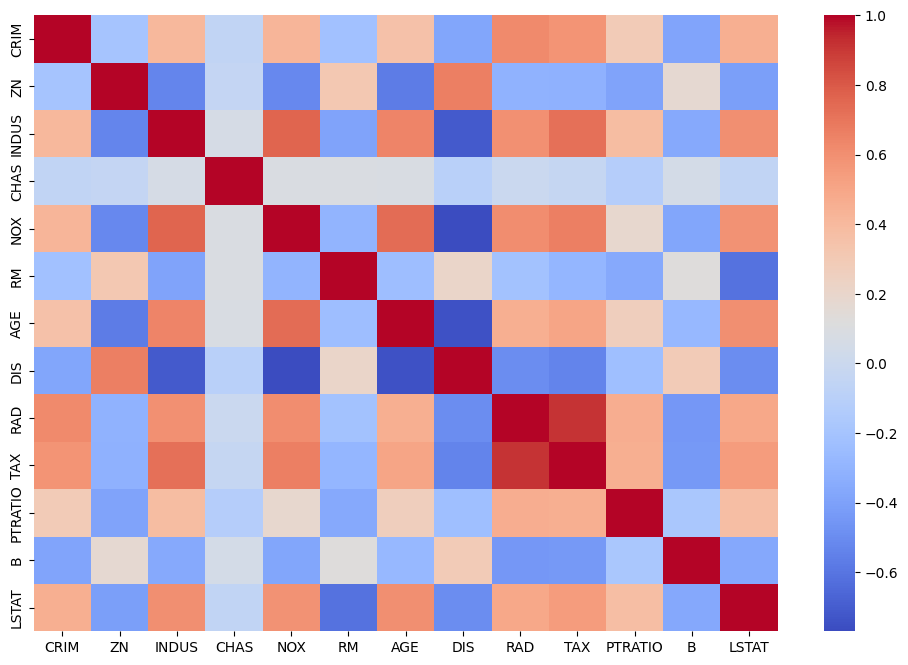

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap='coolwarm')

<Axes: xlabel='MEDV', ylabel='Count'>

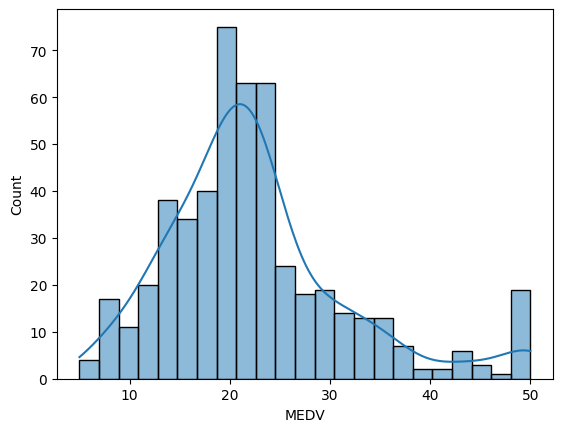

In [9]:
sns.histplot(y, kde=True)

### 2. Linear Regression Model
- Train a Linear Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

In [11]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_pred = lin_model.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

lin_MAE = mean_absolute_error(y_test, lin_pred)
lin_MSE = mean_squared_error(y_test, lin_pred)
lin_RMSE = np.sqrt(lin_MSE)

print(lin_MAE, lin_MSE, lin_RMSE)

3.835696361418934 28.547585271468137 5.34299403625609


Text(0.5, 1.0, 'Residual Plot')

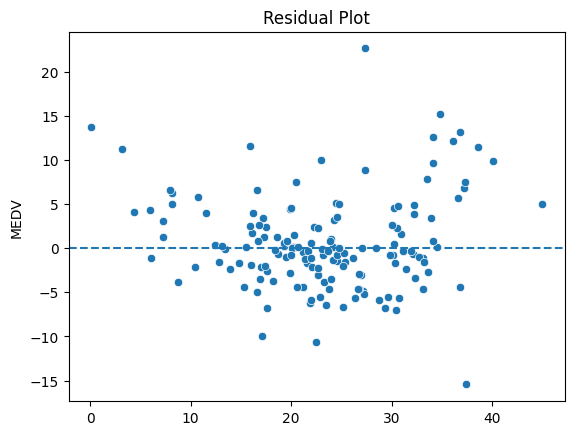

In [13]:
residuals = y_test - lin_pred

sns.scatterplot(x=lin_pred, y=residuals)
plt.axhline(0, linestyle='--')
plt.title("Residual Plot")

### 3. Polynomial Regression Model
- Train a Polynomial Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE


In [14]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

In [15]:
X_train_p, X_test_p, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.3, random_state=101
)

In [16]:
poly_model = LinearRegression()
poly_model.fit(X_train_p, y_train)

poly_pred = poly_model.predict(X_test_p)

In [17]:
poly_MAE = mean_absolute_error(y_test, poly_pred)
poly_MSE = mean_squared_error(y_test, poly_pred)
poly_RMSE = np.sqrt(poly_MSE)

print(poly_MAE, poly_MSE, poly_RMSE)

2.7017035452922133 14.533097371319053 3.812229973561282


In [18]:
train_rmse = []
test_rmse = []

for d in range(1,6):
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)

    X_train_p, X_test_p, y_train, y_test = train_test_split(
        X_poly, y, test_size=0.3, random_state=101
    )

    model = LinearRegression()
    model.fit(X_train_p, y_train)

    train_pred = model.predict(X_train_p)
    test_pred = model.predict(X_test_p)

    train_rmse.append(np.sqrt(mean_squared_error(y_train, train_pred)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, test_pred)))

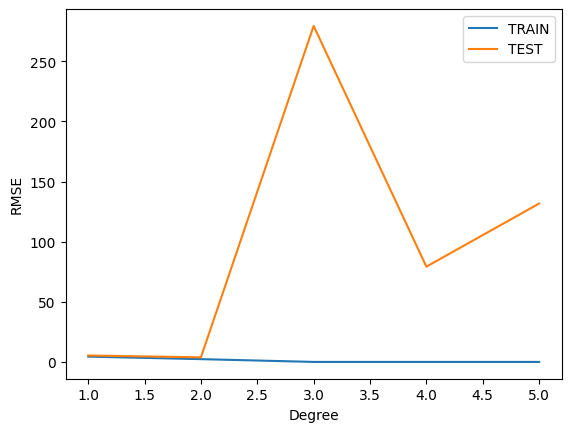

In [19]:
plt.plot(range(1,6), train_rmse, label="TRAIN")
plt.plot(range(1,6), test_rmse, label="TEST")
plt.xlabel("Degree")
plt.ylabel("RMSE")
plt.legend()

In [24]:
best_degree = 2

In [25]:
final_poly = PolynomialFeatures(degree=best_degree, include_bias=False)

X_poly = final_poly.fit_transform(X)

final_model = LinearRegression()
final_model.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 4. Model Comparison
- Compare Linear vs Polynomial Regression results
- Identify which model performs better on the test data and justify your decision


In [ ]:
# Polynomial degree 2 performs better than linear regression because it captures some non-linear relationships.
# Higher degrees overfit, as shown by the large increase in test RMSE.
results = pd.DataFrame({
    "Model": ["Linear", "Polynomial"],
    "MAE": [lin_MAE, poly_MAE],
    "MSE": [lin_MSE, poly_MSE],
    "RMSE": [lin_RMSE, poly_RMSE]
})

results

,Model,MAE,MSE,RMSE
0,Linear,3.835696,28.547585,5.342994
1,Polynomial,2.701704,14.533097,3.812230


In [27]:
pd.Series(lin_model.coef_, index=X.columns)

CRIM       -0.088505
ZN          0.050293
INDUS       0.020348
CHAS        3.754271
NOX       -17.748371
RM          3.247765
AGE         0.012001
DIS        -1.409161
RAD         0.263881
TAX        -0.010344
PTRATIO    -0.951781
B           0.006116
LSTAT      -0.597133
dtype: float64

In [ ]:
# Linear Regression achieved RMSE = 5.34.
# Polynomial Regression with degree 2 achieved RMSE = 3.81.
# Therefore, Polynomial Regression degree 2 is selected as the best model.
# Degree 3 and above were not selected because the test RMSE increased sharply, indicating overfitting.

In [ ]:
# RM has a positive coefficient, meaning more rooms are associated with higher house value.
# LSTAT and PTRATIO have negative coefficients, meaning higher values are associated with lower house value.